<a href="https://colab.research.google.com/github/eyos52/Shahed-Drone-Detection-Targeting/blob/main/ShahedDetectionPipelineColab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Shahed Drone Detection -- Data Pipeline & Model

TI Senior Design, Fall 2026

One notebook, start to finish:

1. **Build the dataset** -- clean and combine every source into one YOLO-format dataset, then oversample the minority `shahed` class so training sees it more often.
2. **Look at the data** -- class balance, per-source composition, sample annotations.
3. **Check data quality** -- box sizes, image resolutions, near-duplicates, train/valid leakage.
4. **Train the model** -- Ultralytics YOLOv8, matching the inference pipeline in the sponsor's notebook (`Shaheed Notebook.ipynb`), so the weights this produces drop straight into that code (both the Ultralytics `.pt` path and the ONNX export path).

Run top to bottom. Steps 1-3 only touch data on disk -- nothing here trains until Step 4, so it's safe to stop and review after any section.

## 0. Setup

This notebook runs in **either** a local Jupyter/VS Code kernel or Google Colab -- the cell below detects which and sets paths accordingly.

**Sections 1-3 (build + review + quality-check the data) are CPU-only** -- file I/O, hashing, image reads. GPU doesn't speed any of that up, and it needs your raw source folders (AOD4, the Shahed sources) which live locally. **Only Section 4 (training) benefits from Colab's GPU.** Two ways to use this in Colab:

1. **Recommended -- build locally, train in Colab.** Run Sections 0-3 here on your Mac as usual to produce `combined_dataset/`. Zip that one folder and upload it (or sync it) into `MyDrive/Shahed_DataSets/combined_dataset` in Google Drive. Then open this same notebook in Colab, run only the setup cell below (mounts Drive, installs packages), skip straight to Section 4, and train with GPU (`Runtime > Change runtime type > GPU`).
2. **Everything in Colab.** Upload *all* your raw source folders into `MyDrive/Shahed_DataSets/` with the same structure they have locally, then run the whole notebook there. Works, but the AOD4 source alone is multiple GB, so the initial upload will take a while.

In [ ]:
from pathlib import Path
import random
import shutil
import hashlib
import sys
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    %pip install -q ultralytics imagehash

    # Point these at wherever you've uploaded/synced your data in Drive (see the note above).
    BASE_DIR = Path("/content/drive/MyDrive/Shahed_DataSets")
    AOD4_DIR = BASE_DIR / "AOD 4"

    # Auto-unzip combined_dataset.zip if that's how you uploaded it and it isn't extracted yet
    zip_path = BASE_DIR / "combined_dataset.zip"
    if zip_path.exists() and not (BASE_DIR / "combined_dataset").exists():
        import zipfile
        print(f"Extracting {zip_path}...")
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(BASE_DIR)
        print("Done.")
else:
    BASE_DIR = Path("/Users/sandra/Documents/Fall 26/Senior Design/DataSets")
    AOD4_DIR = Path("/Users/sandra/Downloads/AOD 4")

OUTPUT_DIR = BASE_DIR / "combined_dataset"
print(f"Running in {'Colab' if IN_COLAB else 'a local kernel'}")
print(f"BASE_DIR = {BASE_DIR}")

FINAL_NAMES = ["other", "shahed"]
VALID_FRACTION = 0.15
RANDOM_SEED = 42

# Palette: fixed categorical order, validated for adjacent-pair contrast
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
INK = "#0b0b0b"
MUTED = "#898781"
GRIDLINE = "#e1e0d9"
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.edgecolor": GRIDLINE,
    "axes.labelcolor": MUTED,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "text.color": INK,
})

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 11.2 MB/s eta 0:00:00
Running in Colab
BASE_DIR = /content/drive/MyDrive/Shahed_DataSets


**Sources**, each with the class remap that folds it into our two final classes (`other`, `shahed`):

- `aod4` -- the full AOD-4 release (airplane / bird / drone / helicopter, ~22.5k images). None of these are Shaheds, so all four fold into `other`.
- `aod4_legacy_roboflow` -- an earlier, smaller helicopter-only export of the same underlying AOD-4 data. Kept so nothing collected goes unused; the MD5 dedup in Step 1b removes anything that turns out to be byte-identical to the full release, so this only ever *adds* genuinely distinct images.
- `shahed_roboflow`, `shahed136_youtube`, `shahed_dataset_1_synthetic` -- the Shahed-136 sources (real photos, YouTube video frames, and synthetic renders).

We take AOD4 **uncapped** -- every image we collected is used. It outnumbers the Shahed sources several times over, so `other`/`shahed` ends up imbalanced; that's handled at training time (class weighting), not by throwing away images.

In [ ]:
SOURCES = [
    {
        "name": "aod4",
        "dirs": [
            (AOD4_DIR / "Images/train", AOD4_DIR / "Annotations/YOLOv8 format/train/labels"),
            (AOD4_DIR / "Images/valid", AOD4_DIR / "Annotations/YOLOv8 format/valid/labels"),
            (AOD4_DIR / "Images/test", AOD4_DIR / "Annotations/YOLOv8 format/test/labels"),
        ],
        "remap": {0: 0, 1: 0, 2: 0, 3: 0},  # airplane, bird, drone, helicopter -> other
    },
    {
        "name": "aod4_legacy_roboflow",
        "dirs": [
            (BASE_DIR / "aod4/train/images", BASE_DIR / "aod4/train/labels"),
            (BASE_DIR / "aod4/valid/images", BASE_DIR / "aod4/valid/labels"),
        ],
        "remap": {0: 0},  # helicopter -> other
    },
    {
        "name": "shahed_roboflow",
        "dirs": [(BASE_DIR / "shahed/train/images", BASE_DIR / "shahed/train/labels")],
        "remap": {0: 0, 1: 1},  # other -> other, shahed -> shahed
    },
    {
        "name": "shahed136_youtube",
        "dirs": [(BASE_DIR / "Shahed-136_youtube_batch2/test/images",
                  BASE_DIR / "Shahed-136_youtube_batch2/test/labels")],
        "remap": {0: 1},  # shahed-136 -> shahed
    },
    {
        "name": "shahed_dataset_1_synthetic",
        "dirs": [(BASE_DIR / "shahed_dataset_1/prepped/images",
                  BASE_DIR / "shahed_dataset_1/prepped/labels")],
        "remap": {1: 1},  # already shahed
    },
]

## 1. Build the combined dataset

### 1a. Clean and remap every source

For each source: match every image to its label file, drop anything unpaired or corrupt, validate every label line, and remap its class ids onto our two final classes.

In [ ]:
def clean_dir_pair(images_dir, labels_dir, remap):
    """Validate one images/labels folder pair. Returns (list of (image_path, boxes), stats)."""
    images_dir, labels_dir = Path(images_dir), Path(labels_dir)
    if not images_dir.exists() or not labels_dir.exists():
        print(f"  !! skipping missing dir pair: {images_dir} / {labels_dir}")
        return [], {}

    image_files = {p.stem: p for p in images_dir.iterdir()
                   if p.suffix.lower() in (".jpg", ".jpeg", ".png")}
    label_files = {p.stem: p for p in labels_dir.iterdir() if p.suffix.lower() == ".txt"}
    stems = sorted(set(image_files) & set(label_files))

    valid_pairs, corrupt_images, bad_lines = [], [], []
    for stem in stems:
        img_path = image_files[stem]
        try:
            with Image.open(img_path) as im:
                im.verify()
        except Exception as e:
            corrupt_images.append((str(img_path), str(e)))
            continue

        boxes = []
        with open(label_files[stem]) as f:
            for line_no, line in enumerate(f):
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                if len(parts) < 5:
                    bad_lines.append((str(label_files[stem]), line_no, line))
                    continue
                try:
                    cls = int(float(parts[0]))
                    x, y, w, h = (float(v) for v in parts[1:5])
                except ValueError:
                    bad_lines.append((str(label_files[stem]), line_no, line))
                    continue
                if cls not in remap:
                    bad_lines.append((str(label_files[stem]), line_no, line))
                    continue
                boxes.append((remap[cls], x, y, w, h))
        valid_pairs.append((img_path, boxes))

    stats = {
        "candidate_images": len(image_files),
        "valid_pairs": len(valid_pairs),
        "missing_labels": len(set(image_files) - set(label_files)),
        "missing_images": len(set(label_files) - set(image_files)),
        "corrupt_images": len(corrupt_images),
        "bad_label_lines": len(bad_lines),
    }
    return valid_pairs, stats


def clean_source(source):
    all_pairs = []
    totals = Counter()
    for images_dir, labels_dir in source["dirs"]:
        pairs, stats = clean_dir_pair(images_dir, labels_dir, source["remap"])
        all_pairs.extend(pairs)
        for k, v in stats.items():
            totals[k] += v
    return all_pairs, {"source": source["name"], **totals}

In [ ]:
print("Cleaning every source...")
all_pairs = []  # (source_name, image_path, boxes)
for source in SOURCES:
    pairs, report = clean_source(source)
    print(report)
    all_pairs.extend((source["name"], img, boxes) for img, boxes in pairs)

print(f"\nTotal valid image/label pairs across all sources: {len(all_pairs)}")

Cleaning every source...
  !! skipping missing dir pair: /content/drive/MyDrive/Shahed_DataSets/AOD 4/Images/train / /content/drive/MyDrive/Shahed_DataSets/AOD 4/Annotations/YOLOv8 format/train/labels
  !! skipping missing dir pair: /content/drive/MyDrive/Shahed_DataSets/AOD 4/Images/valid / /content/drive/MyDrive/Shahed_DataSets/AOD 4/Annotations/YOLOv8 format/valid/labels
  !! skipping missing dir pair: /content/drive/MyDrive/Shahed_DataSets/AOD 4/Images/test / /content/drive/MyDrive/Shahed_DataSets/AOD 4/Annotations/YOLOv8 format/test/labels
{'source': 'aod4'}
  !! skipping missing dir pair: /content/drive/MyDrive/Shahed_DataSets/aod4/train/images / /content/drive/MyDrive/Shahed_DataSets/aod4/train/labels
  !! skipping missing dir pair: /content/drive/MyDrive/Shahed_DataSets/aod4/valid/images / /content/drive/MyDrive/Shahed_DataSets/aod4/valid/labels
{'source': 'aod4_legacy_roboflow'}
  !! skipping missing dir pair: /content/drive/MyDrive/Shahed_DataSets/shahed/train/images / /conte

### 1b. Remove exact duplicate images

Same underlying photo can show up in more than one source (e.g. the legacy AOD4 export overlaps with the full release). Hash every image's bytes and drop repeats.

In [ ]:
def file_md5(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            h.update(chunk)
    return h.hexdigest()

seen_hashes = {}
duplicates = []
deduped_pairs = []  # (source_name, image_path, boxes)
for source_name, img_path, boxes in all_pairs:
    h = file_md5(img_path)
    if h in seen_hashes:
        duplicates.append((str(img_path), seen_hashes[h]))
        continue
    seen_hashes[h] = str(img_path)
    deduped_pairs.append((source_name, img_path, boxes))

print(f"Found {len(duplicates)} exact duplicates (removed)")
print(f"Remaining: {len(deduped_pairs)} images")

Found 0 exact duplicates (removed)
Remaining: 0 images


In [ ]:
print("Contents of Shahed_DataSets:")
for p in sorted(BASE_DIR.iterdir()):
    print(" ", p.name)

nested = BASE_DIR / "combined_dataset"
if nested.exists():
    print("\nContents of Shahed_DataSets/combined_dataset:")
    for p in sorted(nested.iterdir()):
        print(" ", p.name)

Contents of Shahed_DataSets:
  __MACOSX
  combined_dataset
  combined_dataset.zip
  trained_models
  your_video_filename.mp4

Contents of Shahed_DataSets/combined_dataset:
  data.yaml
  train
  valid


### 1c. Split into train/valid

Shuffle once with a fixed seed and split train/valid. This is the *real*, un-oversampled split -- kept as-is and used for every data-quality check and every chart below, so those always reflect what was actually collected, not any synthetic duplication added later.

### 1d. Oversample shahed images (train split only)

`shahed` is a small minority of instances -- oversampling duplicates each shahed-containing training image a few times so the model sees it more often per epoch. This only touches the **train** split (never valid), so the validation score stays honest and comparable across runs.

Each duplicate is just another entry pointing at the same source photo -- during training, Ultralytics re-applies mosaic/flip/color-jitter augmentation independently every time an image is sampled, so repeats aren't literally identical inputs, they're different augmented views of the same real photo seen more often.

This is a volume-of-*exposure* fix, not a substitute for more real images -- it can't teach the model anything a genuinely new photo would, and oversampling too aggressively risks the model memorizing the limited pool of real shahed backgrounds. `TARGET_RATIO` below aims for a more moderate balance rather than a full 1:1 for that reason -- raise or lower it and re-run to see the tradeoff.

### 1e. Write the combined dataset to disk

Copies files into `combined_dataset/` with source-prefixed filenames (so you can always trace an image back to where it came from -- duplicated shahed images get a `__dupeN` suffix), and writes `data.yaml` for training. Uses `train_set_final` (oversampled) for train and the untouched `valid_set` for validation.

In [ ]:
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
    print(f"Cleared previous {OUTPUT_DIR}")

for split_name, split_data in [("train", train_set_final), ("valid", valid_set)]:
    img_out = OUTPUT_DIR / split_name / "images"
    lbl_out = OUTPUT_DIR / split_name / "labels"
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)
    for source_name, img_path, boxes in split_data:
        new_stem = f"{source_name}__{img_path.stem}"
        shutil.copy(img_path, img_out / f"{new_stem}{img_path.suffix.lower()}")
        with open(lbl_out / f"{new_stem}.txt", "w") as f:
            for cls, x, y, w, h in boxes:
                f.write(f"{cls} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

data_yaml_path = OUTPUT_DIR / "data.yaml"
data_yaml_path.write_text(
    f"train: {OUTPUT_DIR}/train/images\n"
    f"val: {OUTPUT_DIR}/valid/images\n\n"
    f"nc: {len(FINAL_NAMES)}\n"
    f"names: {FINAL_NAMES}\n"
)
print(f"\nWrote {OUTPUT_DIR} and {data_yaml_path}")

## 2. Look at the data

Everything below reads from `train_set` / `valid_set` / `deduped_pairs` already in memory -- no need to re-scan disk. These reflect the **real, un-oversampled** data (Step 1d's duplicates only exist in what got written to disk for training in Step 1e), so the chart below still shows the raw imbalance you're trying to fix.

## 3. Data quality checks

Four checks beyond "does every image have a valid label": box size, image resolution, near-duplicates MD5 can't catch, and train/valid leakage.

### 3a. Box size distribution

A detector's hardest cases are small objects. A Shahed at distance can be a handful of pixels -- worth knowing up front how many of our boxes are already that small, since it sets expectations for accuracy. (For reference, published benchmarks for this class of model report small-object mAP around 0.21 vs. ~0.51 for large objects -- roughly a 2.5x gap -- so a dataset skewed toward tiny boxes is a harder training problem, not a data bug.)

### 3b. Label sanity check

`clean_dir_pair` already rejects malformed lines, but it doesn't check whether a box's coordinates are actually *sane* -- inside the image, positive width/height, not covering the whole frame. Catches copy-paste or export bugs from any one source.

In [ ]:
def box_bounds(xc, yc, bw, bh):
    x1, y1 = xc - bw / 2, yc - bh / 2
    x2, y2 = xc + bw / 2, yc + bh / 2
    return x1, y1, x2, y2

out_of_bounds, degenerate, near_full_frame = [], [], []
for source_name, img_path, boxes in train_set + valid_set:
    for cls, xc, yc, bw, bh in boxes:
        x1, y1, x2, y2 = box_bounds(xc, yc, bw, bh)
        if bw <= 0 or bh <= 0:
            degenerate.append((source_name, img_path.name))
        elif x1 < -0.01 or y1 < -0.01 or x2 > 1.01 or y2 > 1.01:
            out_of_bounds.append((source_name, img_path.name))
        elif bw * bh > 0.9:
            near_full_frame.append((source_name, img_path.name))

print(f"Degenerate boxes (zero/negative size): {len(degenerate)}")
print(f"Out-of-bounds boxes (outside the image): {len(out_of_bounds)}")
print(f"Boxes covering >90% of the frame (likely mislabeled): {len(near_full_frame)}")
if near_full_frame:
    print("  sample:", near_full_frame[:5])

Degenerate boxes (zero/negative size): 0
Out-of-bounds boxes (outside the image): 0
Boxes covering >90% of the frame (likely mislabeled): 0


### 3c. Near-duplicate check (beyond exact-byte MD5)

MD5 only catches byte-identical files. A resize, recompress, or re-export of the same photo -- likely between `aod4` and `aod4_legacy_roboflow`, which trace back to the same underlying collection -- produces a different hash but a visually identical image. Perceptual hashing (`imagehash`) catches those.

`pip install imagehash` if you don't have it. This hashes every image in the combined dataset; expect a few minutes for the full ~31k.

In [ ]:
try:
    import imagehash
except ImportError:
    %pip install -q imagehash
    import imagehash

def compute_phash(img_path):
    try:
        return str(imagehash.phash(Image.open(img_path)))
    except Exception:
        return None

phash_to_images = {}
for i, (source_name, img_path, boxes) in enumerate(train_set + valid_set):
    h = compute_phash(img_path)
    if h is not None:
        phash_to_images.setdefault(h, []).append((source_name, img_path))
    if (i + 1) % 5000 == 0:
        print(f"  hashed {i + 1} images...")

near_dupe_groups = {h: v for h, v in phash_to_images.items() if len(v) > 1}
print(f"\nFound {len(near_dupe_groups)} groups of near-duplicate images "
      f"({sum(len(v) - 1 for v in near_dupe_groups.values())} redundant images total)")

sample_groups = list(near_dupe_groups.items())[:5]
for h, group in sample_groups:
    print("  ", [f"{s}/{p.name}" for s, p in group])


Found 0 groups of near-duplicate images (0 redundant images total)


### 3d. Train/valid leakage check

The near-duplicate groups above tell us something more important than redundancy: if a near-duplicate pair got split across train and valid, the model is partly being validated on images it effectively already saw in training -- an inflated validation score. Check for that specifically.

In [ ]:
train_paths = {img_path for _, img_path, _ in train_set}
valid_paths = {img_path for _, img_path, _ in valid_set}

leaked_groups = []
for h, group in near_dupe_groups.items():
    paths = {p for _, p in group}
    if paths & train_paths and paths & valid_paths:
        leaked_groups.append(group)

print(f"Near-duplicate groups split across train/valid: {len(leaked_groups)}")
for group in leaked_groups[:5]:
    print("  ", [f"{s}/{p.name}" for s, p in group])
if leaked_groups:
    print("\nIf this count is non-trivial, re-split so near-duplicate groups stay "
          "together on one side (group-aware split) rather than a plain random shuffle.")

Near-duplicate groups split across train/valid: 0


### 3e. Image resolution spread

Wildly different resolutions across sources (synthetic renders vs. YouTube frames vs. Roboflow exports) affect how much detail survives the resize YOLO does internally. Good to know before picking `imgsz` for training.

/tmp/ipykernel_706/2784551677.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=8)


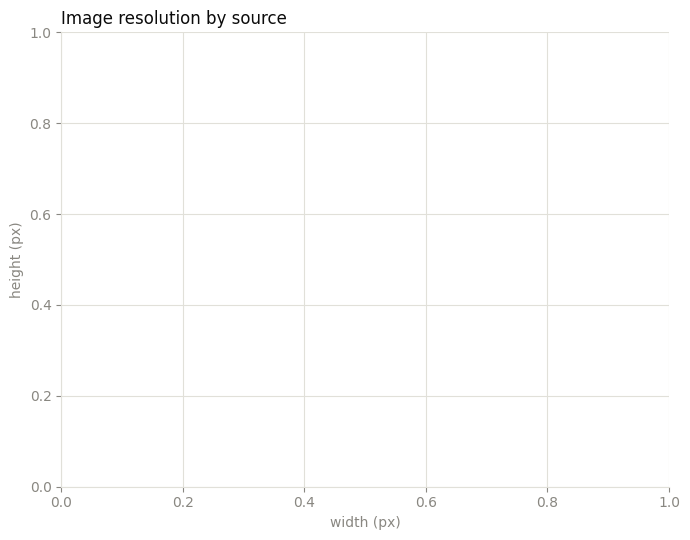

In [ ]:
resolutions_by_source = {}
for source_name, img_path, _ in deduped_pairs:
    with Image.open(img_path) as im:
        w, h = im.size
    resolutions_by_source.setdefault(source_name, []).append((w, h))

fig, ax = plt.subplots(figsize=(7, 5.5))
for i, (source_name, res_list) in enumerate(sorted(resolutions_by_source.items())):
    ws = [w for w, h in res_list]
    hs = [h for w, h in res_list]
    ax.scatter(ws, hs, s=6, alpha=0.4, color=PALETTE[i % len(PALETTE)], label=source_name)
ax.set_xlabel("width (px)")
ax.set_ylabel("height (px)")
ax.set_title("Image resolution by source", color=INK, fontsize=12, loc="left")
ax.grid(color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## 4. Train the model

Your sponsor's own notebook loads a custom-trained Ultralytics checkpoint (`best_shahed_100_iter.pt`) and also runs an ONNX export of it. This trains a new checkpoint the same way, on the combined dataset above, so the result drops straight into that existing inference code -- both the Ultralytics `.pt` path and the ONNX path.

Picks the fastest device available automatically: a Colab GPU if you're there (make sure `Runtime > Change runtime type` is set to GPU first), otherwise Apple Silicon's MPS, otherwise CPU. 100 epochs on CPU is impractically slow -- that's the whole reason to move this to Colab.

**Jumping straight here without running Sections 1-3 in this session** (the normal Colab flow -- you built `combined_dataset/` locally and just uploaded/synced it)? You still need to run the **Section 0 setup cell** first, so `BASE_DIR` / `OUTPUT_DIR` are defined and Drive is mounted. The cell below then locates `data.yaml` on disk itself -- it doesn't depend on `train_set` / `valid_set` being in memory.

In [ ]:
data_yaml_path = OUTPUT_DIR / "data.yaml"
assert data_yaml_path.exists(), (
    f"{data_yaml_path} not found. Make sure combined_dataset/ (built in Section 1, or "
    f"uploaded/synced from your Mac) is at that exact path, and that you've run the "
    f"Section 0 setup cell in this session."
)

# data.yaml may have been written on a different machine than this one -- e.g. built
# locally, then zipped and uploaded to Drive -- in which case its train/val paths are
# absolute paths from THAT machine and won't exist here. Rewrite them to match wherever
# OUTPUT_DIR actually is right now, so training works no matter where this runs.
data_yaml_path.write_text(
    f"train: {OUTPUT_DIR}/train/images\n"
    f"val: {OUTPUT_DIR}/valid/images\n\n"
    f"nc: {len(FINAL_NAMES)}\n"
    f"names: {FINAL_NAMES}\n"
)
print(f"Found dataset: {data_yaml_path} (train/val paths rewritten to match this machine)")

Found dataset: /content/drive/MyDrive/Shahed_DataSets/combined_dataset/data.yaml (train/val paths rewritten to match this machine)


In [ ]:
data_yaml_path = OUTPUT_DIR / "data.yaml"
assert data_yaml_path.exists(), (
    f"{data_yaml_path} not found. Make sure combined_dataset/ (built in Section 1, or "
    f"uploaded/synced from your Mac) is at that exact path, and that you've run the "
    f"Section 0 setup cell in this session."
)
print(f"Found dataset: {data_yaml_path}")

NameError: name 'OUTPUT_DIR' is not defined

In [ ]:
train_dir = OUTPUT_DIR / "train"
print("Contents of train/:")
for p in sorted(train_dir.iterdir()):
    print(" ", p.name, "(dir)" if p.is_dir() else f"{p.stat().st_size} bytes")

images_dir = train_dir / "images"
if images_dir.exists():
    imgs = list(images_dir.iterdir())
    print(f"\n{len(imgs)} files in train/images")
    print("sample:", [f.name for f in imgs[:5]])

valid_dir = OUTPUT_DIR / "valid"
valid_labels = valid_dir / "labels"
if valid_labels.exists():
    print(f"\n{len(list(valid_labels.iterdir()))} files in valid/labels")

Contents of train/:
  images (dir)
  labels (dir)
  labels.cache 9444141 bytes

21828 files in train/images
sample: ['shahed_dataset_1_synthetic__qexpxmcwueavgtivoavdfkiq0000.jpg', 'aod4_legacy_roboflow__yt-5KOIhxSH7lw-0430_jpg.rf.2ebd2a1f8ea7a70d913a664415c7d968.jpg', 'aod4_legacy_roboflow__V_HELICOPTER_006230_252_png_jpg.rf.91e6c7e38784069fc464338afacb0dde.jpg', 'aod4__yt-bwGKBfCw0kc-0139_jpg.rf.16c9e63a2078bd236b74b672a5de4e09.jpg', 'aod4__yt-HPJzQpwqZ4s-0017_jpg.rf.e5308a8f6a05739c41c6034ccf8791aa.jpg']

4732 files in valid/labels


In [ ]:
import shutil, zipfile
from pathlib import Path

local_zip = Path("/content/combined_dataset.zip")
if not local_zip.exists():
    print("Copying zip from Drive to local disk (one big fast copy)...")
    shutil.copy(BASE_DIR / "combined_dataset.zip", local_zip)

OUTPUT_DIR = Path("/content/combined_dataset")
if not OUTPUT_DIR.exists():
    print("Extracting locally...")
    with zipfile.ZipFile(local_zip) as zf:
        zf.extractall("/content")

data_yaml_path = OUTPUT_DIR / "data.yaml"
data_yaml_path.write_text(
    f"train: {OUTPUT_DIR}/train/images\n"
    f"val: {OUTPUT_DIR}/valid/images\n\n"
    f"nc: {len(FINAL_NAMES)}\n"
    f"names: {FINAL_NAMES}\n"
)
print(f"Dataset is now local at {OUTPUT_DIR} — training should be fast now.")

Copying zip from Drive to local disk (one big fast copy)...
Extracting locally...
Dataset is now local at /content/combined_dataset — training should be fast now.


In [ ]:
try:
    from ultralytics import YOLO
except ImportError:
    %pip install -q ultralytics
    from ultralytics import YOLO

import torch

if torch.cuda.is_available():
    device = 0
    print(f"Training on GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = "mps"
    print("Training on Apple Silicon (MPS) -- fine for a smoke test, slow for a full run")
else:
    device = "cpu"
    print("No GPU/MPS found -- training on CPU. In Colab: Runtime > Change runtime type > GPU")

model = YOLO("yolov8n.pt")  # start from the pretrained nano checkpoint

train_results = model.train(
    data=str(data_yaml_path),
    epochs=100,
    imgsz=640,          # match whatever input size your deployment/ONNX pipeline expects
    batch=16,
    device=device,
    name="shahed_detector",
    patience=20,        # stop early if validation stalls
)

Training on GPU: NVIDIA A100-SXM4-40GB
Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/combined_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=

### 4a. Quick check on the trained weights

Same pattern as your sponsor's "easy way" cell -- load the best checkpoint from this run and predict on a single image before doing anything else with it.

In [ ]:
best_weights = Path(train_results.save_dir) / "weights" / "best.pt"
print(f"Best weights: {best_weights}")

trained_model = YOLO(str(best_weights))
sample_img = next((OUTPUT_DIR / "valid" / "images").iterdir())  # reads from disk -- no in-memory valid_set needed
result = trained_model(str(sample_img))[0]

# plt.imshow instead of result.show() -- more reliable in Colab/Jupyter than a popup window
plt.figure(figsize=(8, 8))
plt.imshow(result.plot()[:, :, ::-1])  # BGR -> RGB
plt.axis("off")
plt.show()

NameError: name 'Path' is not defined

### 4b. Export to ONNX

Matches the model file your sponsor's ONNX-runtime cell (`yolov8n_best.onnx`) expects.

In [ ]:
onnx_path = trained_model.export(format="onnx")
print(f"Exported: {onnx_path}")

Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/shahed_detector-2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 241ms
Prepared 5 packages in 261ms
Uninstalled 1 package in 4ms
Installed 5 packages in 29ms
 + colorama==0.4.6
 + onnx==1.23.1
 + onnxruntime==1.30.0
 + onnxslim==0.1.97
 - protobuf==5.29.6
 + protobuf==7.36.2

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take 

### 4c. If you're in Colab: save the weights before the runtime disconnects

Colab's local disk (`/content/...`, where `runs/` and the exported ONNX land) is wiped when the runtime recycles -- copy the weights into Drive right away.

In [ ]:
if IN_COLAB:
    drive_weights_dir = BASE_DIR / "trained_models"
    drive_weights_dir.mkdir(exist_ok=True)
    shutil.copy(best_weights, drive_weights_dir / "shahed_best.pt")
    shutil.copy(onnx_path, drive_weights_dir / "shahed_best.onnx")
    print(f"Saved weights to {drive_weights_dir}")
else:
    print("Not in Colab -- weights are already on local disk, nothing extra to do.")

NameError: name 'best_weights' is not defined

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
trained_model = YOLO("/content/drive/MyDrive/Shahed_DataSets/trained_models/shahed_best.pt")

results = trained_model.predict(
    source="/content/drive/MyDrive/Shahed_DataSets/your_video_filename.mp4",  # path to your video
    save=True,        # writes an annotated output video
    conf=0.25,        # confidence threshold -- lower catches more, riskier false positives
    imgsz=640,
)


print(f"Annotated video saved to: {results[0].save_dir}")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/703) /content/drive/MyDrive/Shahed_DataSets/your_video_filename.mp4: 352x640 (no detections), 7.3ms
video 1/1 (frame 2/703) /content/drive/MyDrive/Shahed_DataSets/your_video_filename.mp4: 352x640 (no detections), 8.5ms
video 1/1 (frame 3/703) /content/drive/MyDrive/Shahed_DataSets/your_video_filename.mp4: 352x640 (no detections), 7.9ms
video 1/1 (frame 4/703) /content/drive/MyDrive/Shahed_DataSets/your_video_filename.mp4: 352x640 (no de

In [ ]:
trained_model = YOLO("/content/drive/MyDrive/Shahed_DataSets/trained_models/shahed_best.pt")

results = trained_model.predict(
    source="/content/drive/MyDrive/Shahed_DataSets/Screen Recording 2026-09-30 at 12.08.54 PM.mov",  # path to your video
    save=True,        # writes an annotated output video
    conf=0.25,        # confidence threshold -- lower catches more, riskier false positives
    imgsz=640,
)


print(f"Annotated video saved to: {results[0].save_dir}")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/689) /content/drive/MyDrive/Shahed_DataSets/Screen Recording 2026-09-30 at 12.08.54 PM.mov: 352x640 1 other, 6.8ms
video 1/1 (frame 2/689) /content/drive/MyDrive/Shahed_DataSets/Screen Recording 2026-09-30 at 12.08.54 PM.mov: 352x640 2 others, 7.3ms
video 1/1 (frame 3/689) /content/drive/MyDrive/Shahed_DataSets/Screen Recording 2026-09-30 at 12.08.54 PM.mov: 352x640 2 others, 6.8ms
video 1/1 (frame 4/689) /content/drive/MyDrive/Shahed_D

In [ ]:
from google.colab import files
import os

save_dir = results[0].save_dir
output_file = os.listdir(save_dir)[0]  # grabs the annotated video's filename
print(f"Downloading: {output_file}")

files.download(os.path.join(save_dir, output_file))
import shutil
shutil.copy(os.path.join(save_dir, output_file),
            "/content/drive/MyDrive/Shahed_DataSets/annotated_output.avi")

Downloading: Screen Recording 2026-09-30 at 12.08.54 PM.avi


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'/content/drive/MyDrive/Shahed_DataSets/annotated_output.avi'

In [ ]:
from google.colab import files
files.download("/content/runs/detect/predict/your_video_filename.avi")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Next steps

- Review Section 3 above -- especially 3c/3d -- before trusting the validation split. If leakage or a lot of near-duplicates turn up, re-run Step 1c with a group-aware split.
- Try a couple of `TARGET_RATIO` values in Step 1d and compare validation shahed recall/precision -- oversampling too hard toward 1:1 can start hurting more than it helps once the model starts memorizing the limited real shahed backgrounds.
- Once you're happy with the data, run Section 4. `epochs=100` / `patience=20` is a reasonable starting point -- adjust after watching the first run's loss curves (`runs/detect/shahed_detector/results.png`).
- Evaluate precision/recall per class on the held-out split, not just aggregate mAP -- `shahed` is the class that actually matters and it's also the minority class.
- Hand the exported `best.onnx` (and `best.pt`) to your sponsor's existing inference notebook to compare against the current `best_shahed_100_iter.pt`.